In [2]:
# No code needed in this cell
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START,END
from dotenv import load_dotenv
from groq import Groq
from langchain_groq import ChatGroq

load_dotenv()

True

In [3]:
class SubsState(TypedDict):
    input_text: str
    translated_text: str

In [4]:
llm =  ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.3
)

In [6]:
def translate_text(state: SubsState) -> SubsState:
    '''
    Translate the input text to Telugu while preserving names and proper nouns.

    Args:
        state: A dictionary containing the input text.

    Returns:
        A dictionary containing the translated text.
    '''
    prompt = f"Translate the following text to Telugu. Keep it natural and clear. Do not translate any names or proper nouns. Text: {state['input_text']}"
    translated_text = llm.invoke(prompt).content
    return {"translated_text": translated_text.strip()}

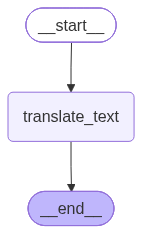

In [8]:
subgraph_builder = StateGraph(SubsState)
subgraph_builder.add_node("translate_text",translate_text)

subgraph_builder.add_edge(START, "translate_text")
subgraph_builder.add_edge("translate_text", END)

subgraph = subgraph_builder.compile()
subgraph

In [9]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_telugu: str

In [10]:
parent_llm =  ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [11]:
def generate_answer(state: ParentState) -> ParentState:
    '''
    Generate an answer to the question in English.

    Args:
        state: A dictionary containing the question.
    Returns:
        A dictionary containing the answer in English.
    '''
    answer = parent_llm.invoke(f"Answer the following question in English: {state['question']}").content
    return {"answer_eng": answer.strip()}
    

In [12]:
def translate_text(state: ParentState) -> ParentState:
    '''
    Translate the input text to Telugu.

    Args:
        state: A dictionary containing the input text.

    Returns:
        A dictionary containing the translated text in Telugu.
    '''
    result = subgraph.invoke({"input_text": state['answer_eng']})
    return {"answer_telugu": result['translated_text']}


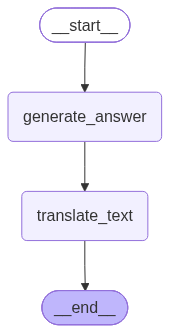

In [13]:
parent_graph_builder = StateGraph(ParentState)
parent_graph_builder.add_node("generate_answer", generate_answer)
parent_graph_builder.add_node("translate_text", translate_text)

parent_graph_builder.add_edge(START, "generate_answer")
parent_graph_builder.add_edge("generate_answer", "translate_text")
parent_graph_builder.add_edge("translate_text", END)

parent_graph = parent_graph_builder.compile()
parent_graph

In [15]:
parent_graph.invoke({"question": "Describe India in 100 words"})

{'question': 'Describe India in 100 words',
 'answer_eng': "India, a vast South Asian nation, blends ancient traditions with rapid modernity. Its diverse landscape spans Himalayan peaks, fertile plains, arid deserts, and tropical coastlines. Home to over 1.4\u202fbillion people, it hosts myriad languages, religions, and cultures, from Hindu festivals to Islamic bazaars, Sikh temples to Christian churches. The economy thrives on technology, agriculture, and manufacturing, while Bollywood films captivate global audiences. Architectural marvels like the Taj\u202fMahal and bustling markets reflect centuries of history. Culinary flavors range from spicy curries to sweet desserts. Despite challenges such as poverty and pollution, India's resilience and innovation drive its dynamic future for generations.",
 'answer_telugu': 'భారతదేశం, విస్తారమైన దక్షిణాసియా దేశం, పురాతన సంప్రదాయాలను వేగవంతమైన ఆధునికతతో కలిపి జీవిస్తుంది. దాని వైవిధ్యమైన భూభాగం హిమాలయ శిఖరాలు, పండుగలైన సమతలాలు, ఎడారుల వాతావరణ